# *K-NN: K-Nearest Neighbors Regressor (KNN Regressor)*

## 1. Carga de Datos

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path

Configuración para que se cree en la carpeta models en la raiz

In [3]:
carpeta_notebooks = Path.cwd()
raiz_proyecto = carpeta_notebooks.parent
carpeta_models = raiz_proyecto / "models"
carpeta_models.mkdir(parents=True, exist_ok=True)

#print(f"📁 Raíz detectada: {raiz_proyecto}")
#print(f"💾 Carpeta de destino del modelo: {carpeta_models}\n")

Carga del dataset Limpio

In [4]:
csv_path = raiz_proyecto / "data" / "clean" / "players_clean.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo en: {csv_path}")

df = pd.read_csv(csv_path)

print("⚙️ Preparando características y limpieza de nulos...")

⚙️ Preparando características y limpieza de nulos...


## 2. Preparación de los datos

### Asegurandose de que no existen valores Nulos

In [5]:
df['age'] = df['age'].fillna(df['age'].median())
df['height_in_cm'] = df['height_in_cm'].fillna(df['height_in_cm'].median())
df['position'] = df['position'].fillna('Missing').astype(str)
df['market_value_in_eur'] = df['market_value_in_eur'].fillna(0)

### Variables de Entrada y Objetivo (X e Y)

In [6]:
columnas = ['age', 'height_in_cm', 'position']
X = df[columnas]
y = df['market_value_in_eur']

## 3. Pipeline de Prepocesamiento (Conversión a números y escalado)

### Transformador de Columnas (Categóricas y Escalado)

Creamos el preprocesador que tratará cada columna de manera independiente:

* Las numéricas se estandarizan (StandardScaler)

* Las categóricas se convierten a binarias/numéricas (OneHotEncoder)

In [7]:
columnas_numericas = ['age', 'height_in_cm']
columnas_categoricas = ['position']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_categoricas)
    ]
)

## 4. Configuración de K-FOLD CROSS-VALIDATION

In [8]:
print("\n🚀 Iniciando K-Fold Cross-Validation con métricas de error (MAE, MSE, RMSE)...")


🚀 Iniciando K-Fold Cross-Validation con métricas de error (MAE, MSE, RMSE)...


In [9]:
# Usamos 5 bloques (Folds). shuffle=True mezcla aleatoriamente los datos antes de separar
kf = KFold(n_splits=5, shuffle=True, random_state=42)

## 5. Validación Cruzada y Entrenamiento del Pipeline K-NN

In [10]:
# Instanciamos el regresor KNN
knn_model = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)

In [11]:
# Unificamos el preprocesamiento y el modelo dentro del Pipeline definitivo
pipeline_knn = Pipeline(steps=[
    ('preprocesador', preprocessor),
    ('modelo', knn_model)
])

print("\n🚀 Ejecutando K-Fold Cross-Validation (K=5)...")


🚀 Ejecutando K-Fold Cross-Validation (K=5)...


In [12]:
# Medimos el Coeficiente de Determinación (R²) de forma robusta en los 5 bloques
scores_r2 = cross_val_score(pipeline_knn, X, y, cv=kf, scoring='r2', n_jobs=-1)

print(f"   📊 R² por cada iteración (Fold): {scores_r2}")
print(f"   📈 Promedio R² de Validación Cruzada: {np.mean(scores_r2):.4f} (+/- {np.std(scores_r2):.4f})")

   📊 R² por cada iteración (Fold): [-0.14564688 -0.14864553 -0.19103796 -0.04488287 -0.16244499]
   📈 Promedio R² de Validación Cruzada: -0.1385 (+/- 0.0495)


In [13]:
# --- DIVISIÓN DE CONTROL DE OVERFITTING Y EVALUACIÓN DE RESIDUOS ---
# Usamos un 20% para validación de métricas directas y gráficos, manteniendo el random_state=42
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n🧠 Entrenando el Pipeline KNN final...")
pipeline_knn.fit(X_train, y_train)

# Predicciones para evaluar sobreajuste
y_pred_train = pipeline_knn.predict(X_train)
y_pred_val = pipeline_knn.predict(X_val)


🧠 Entrenando el Pipeline KNN final...


In [14]:
# Guardamos el pipeline completo (.pkl) de forma segura en la raíz
filename = carpeta_models / "knn_regressor_model.pkl"
joblib.dump(pipeline_knn, filename)
#print(f"   💾 Guardado de forma absoluta en: '{filename}'\n")

['c:\\Users\\Flor\\Desktop\\Programacion\\DA-Project-Regression-Grupo2\\models\\knn_regressor_model.pkl']

## 6. Informe de Métricas de Regresión y Control de Overfitting (< 5%)

## 7. Demostraciones Gráficas de Rendimiento

In [15]:
print("📊 Generando demostraciones gráficas para el análisis...")

📊 Generando demostraciones gráficas para el análisis...


In [16]:
# Realizamos predicciones globales para evaluar visualmente el comportamiento
y_pred = pipeline_knn.predict(X)
errores = y - y_pred

In [17]:
# Activamos el estilo visual de seaborn
sns.set_theme(style="whitegrid")

### Gráfico 1: Valores Reales vs Predicciones


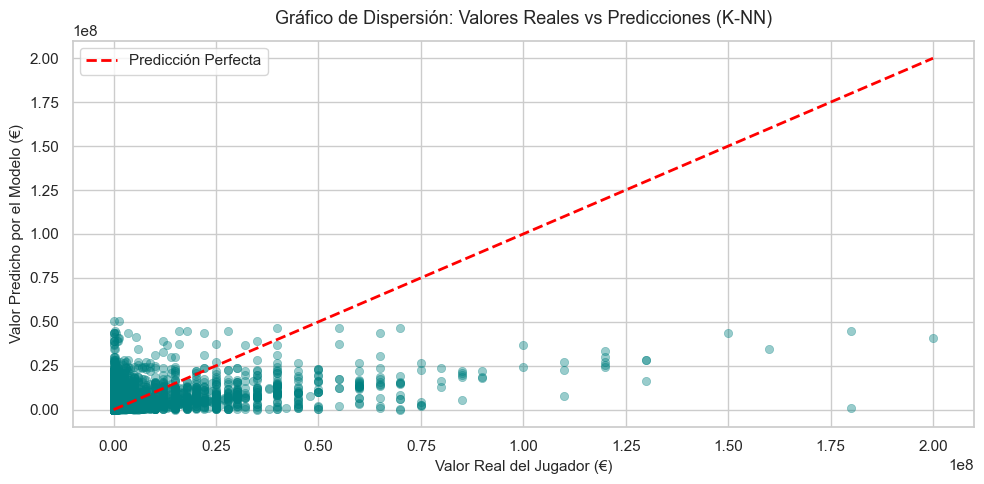

In [18]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y, y=y_pred, alpha=0.4, color='teal', edgecolor=None)

# Línea diagonal ideal (Predicción Perfecta)
max_val = max(max(y), max(y_pred))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

plt.title('Gráfico de Dispersión: Valores Reales vs Predicciones (K-NN)', fontsize=13, pad=12)
plt.xlabel('Valor Real del Jugador (€)', fontsize=11)
plt.ylabel('Valor Predicho por el Modelo (€)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

### Gráfico 2: Distribución de Errores (Residuos)

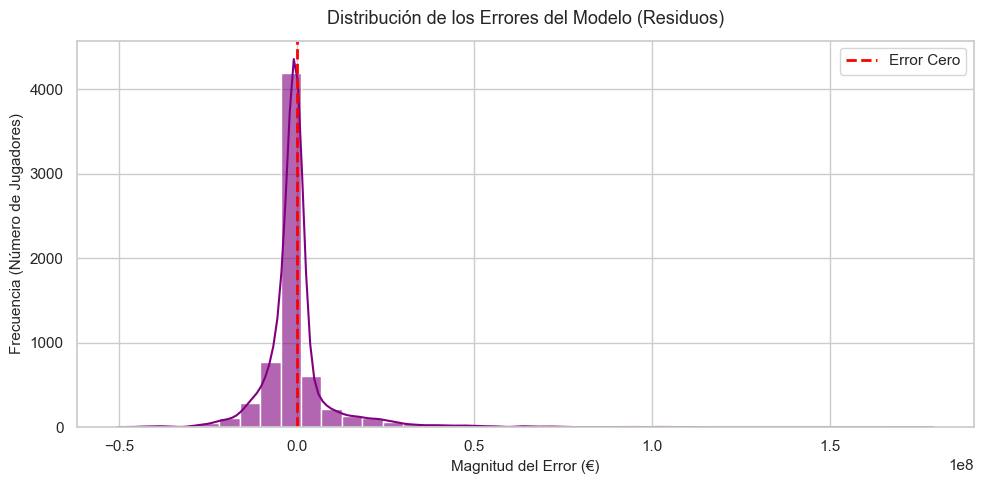

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(errores, kde=True, color='purple', bins=40, alpha=0.6)

# Línea vertical de referencia en el error cero
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error Cero')

plt.title('Distribución de los Errores del Modelo (Residuos)', fontsize=13, pad=12)
plt.xlabel('Magnitud del Error (€)', fontsize=11)
plt.ylabel('Frecuencia (Número de Jugadores)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
print("✨ ¡Proceso completado! Modelo guardado y gráficos generados con éxito.")

✨ ¡Proceso completado! Modelo guardado y gráficos generados con éxito.
